# BinWaves example in Cantabria (Validation)

**In this notebook**: 
<br><br>
Here waves are reconstructed at the buoy location for comparison.
<br><br>
Steps:
- Buoy is loaded.
- Kp propagation coefficients and hindcast reconstruction is made at the buoy location.
- Comparison plots and statistics are shown.

In [1]:
import pandas as pd
import xarray as xr
import numpy as np

# Define buoy locations dictionary with both UTM and WGS84 coordinates
# if not buoys available  just run plot_selected_bathy(bathy=bathy)
buoys= {
         '44088':(-74.8390,36.6120),
         '44100':(-75.5930,36.2580),
         '44086':(-75.4210,36.0010),
         '44056':(-75.7140,36.2000),
         '44095':(-75.3300,35.7500),
         '41120':(-75.2850,35.2580),
         '41025':(-75.4540,35.0100),
         '41159':(-76.9440,34.2110),
         '41110':(-77.7150,34.1420),
         '41013':(-77.7640,33.4410),
         '41108':(-78.0160,33.7210),
}

def find_site_index(kp_coeffs, target_x, target_y, tolerance=1.0):
    """
    Find the site index in kp_coeffs that matches the target coordinates.
    
    Parameters:
    -----------
    kp_coeffs : xarray.Dataset
        The kp coefficients dataset
    target_x : float
        Target UTM x coordinate
    target_y : float
        Target UTM y coordinate
    tolerance : float
        Tolerance for coordinate matching (in meters)
        
    Returns:
    --------
    int
        The site index that matches the coordinates
    """
    # Get all site coordinates
    site_x = kp_coeffs.utm_x.values
    site_y = kp_coeffs.utm_y.values
    
    # Calculate distances to all sites
    distances = np.sqrt((site_x - target_x)**2 + (site_y - target_y)**2)
    
    # Find the site with minimum distance
    site_index = np.argmin(distances)
    
    # Check if the closest site is within tolerance
    if distances[site_index] > tolerance:
        print(f"Warning: Closest site is {distances[site_index]:.2f} meters away")
    
    return site_index

def load_buoy_data(buoy_id, year=None):
    """
    Load buoy data and return both the wave data and location coordinates.
    
    Parameters:
    -----------
    buoy_id : str
        The buoy ID (e.g., '44100')
    year : str, optional
        The year to filter data for (default: None)
        
    Returns:
    --------
    tuple
        (buoy_waves, buoy_location, kp_coeffs)
    """
    # Load buoy data
    buoy_waves = pd.read_pickle(f"outputs/buoy_{buoy_id}_bulk_parameters.pkl").sort_index()
    if year:
        buoy_waves = buoy_waves.loc[year]
    buoy_waves = buoy_waves.dropna(subset=['Hs_Buoy', 'Tp_Buoy', 'Dir_Buoy'])
    
    # Get buoy location (both UTM and WGS84)
    buoy_location = buoys[buoy_id]
    
    # Load kp coefficients
    kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc")
    
    # Find the correct site index
    site_index = find_site_index(kp_coeffs, buoy_location[0], buoy_location[1])
    
    # Select the correct site
    kp_coeffs = kp_coeffs.isel(site=[site_index])
    
    return buoy_waves, buoy_location, kp_coeffs

# Example usage:
buoy_id = "44056"  # Change this to use different buoys
buoy_waves, buoy_location, kp_coeffs = load_buoy_data(buoy_id,'2023')

# Print the coordinates for verification
print(f"Buoy {buoy_id} coordinates:")
print(f"WGS84: {buoy_location[0]}, {buoy_location[1]}")
print(f"\nSelected kp_coeffs site coordinates:")
print(f"{kp_coeffs.utm_x.values}, {kp_coeffs.utm_y.values}")

Buoy 44056 coordinates:
WGS84: -75.714, 36.2

Selected kp_coeffs site coordinates:
[-75.714], [36.2]


In [ ]:
# import pandas as pd
# import xarray as xr

# # Load buoy data and kps

# buoy_waves = pd.read_pickle("outputs/buoy_44088_bulk_parameters.pkl").sort_index().loc["2022"]

# kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc").isel(site=[-11])
# kp_coeffs

In [2]:
kp_coeffs.utm_x.values, kp_coeffs.utm_y.values

(array([-75.714]), array([36.2]))

## Offshore Spectrum

> ⚠️ **NOTE:** If satellite correction was applied, ensure that 'satellite_correction=True'. The default value is False.

In [3]:
from utils.operations import transform_ERA5_spectrum

model_parameters = pd.read_csv("NC_SC/swan_cases.csv").to_dict(orient="list")

# Load interest spectra
offshore_spectra, offshore_spectra_case = (
    transform_ERA5_spectrum(
        era5_spectrum=xr.open_dataset("outputs/satellite_corrected_44088_spectrum_cal.nc"),
        subset_parameters=model_parameters,
        available_case_num=kp_coeffs.case_num.values,
        satellite_correction=True,
    )
)
offshore_spectra_case

<xarray.DataArray 'efth' (case_num: 695, time: 405963)> Size: 2GB
array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.71341895e-19],
       ...,
       [0.00000000e+00, 6.08661044e-27, 2.46071238e-22, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 3.85256781e-27, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 7.15261264e-25, 8.06842138e-23, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
      shape=(695, 405963))
Coordinates:
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695
  * time      (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01
    station   int32 4B 133

In [5]:
from bluemath_tk.waves.binwaves import reconstruc_spectra
import numpy as np
# First, ensure unique times in offshore_spectra_case
_, unique_idx_offshore = np.unique(offshore_spectra_case.time, return_index=True)
offshore_spectra_case = offshore_spectra_case.isel(time=unique_idx_offshore)

# Then, ensure unique times in buoy_waves
buoy_waves = buoy_waves[~buoy_waves.index.duplicated(keep='first')]


reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=buoy_waves.index, method="nearest"),
    kp_coeffs=kp_coeffs,
    num_workers=8,
)
reconstructed_onshore_spectra

/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-stable/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46373 instead
  warnings.warn(
/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-stable/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 87.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.Dataset> Size: 98MB
Dimensions:  (site: 1, freq: 31, dir: 24, time: 16460)
Coordinates:
  * site     (site) int64 8B 529
  * freq     (freq) float64 248B 0.03 0.0329 0.0362 0.0397 ... 0.4145 0.4552 0.5
  * dir      (dir) float64 192B 2.5 17.5 32.5 47.5 ... 302.5 317.5 332.5 347.5
    lat      float64 8B 0.0
    lon      float64 8B 0.0
    utm_x    (site) float64 8B -75.71
    utm_y    (site) float64 8B 36.2
  * time     (time) datetime64[ns] 132kB 2023-01-01 ... 2023-12-18
    station  int32 4B 133
Data variables:
    kps      (time, site, freq, dir) float64 98MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-stable/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)
/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-stable/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: xlabel='Hs - Buoy [m]', ylabel='Hs - BinWaves [m]'>,
        <Axes: xlabel='Tp - Buoy [s]', ylabel='Tp - BinWaves [s]'>,
        <Axes: xlabel='Dir - Buoy [°]', ylabel='Dir - BinWaves [°]'>],
       dtype=object))

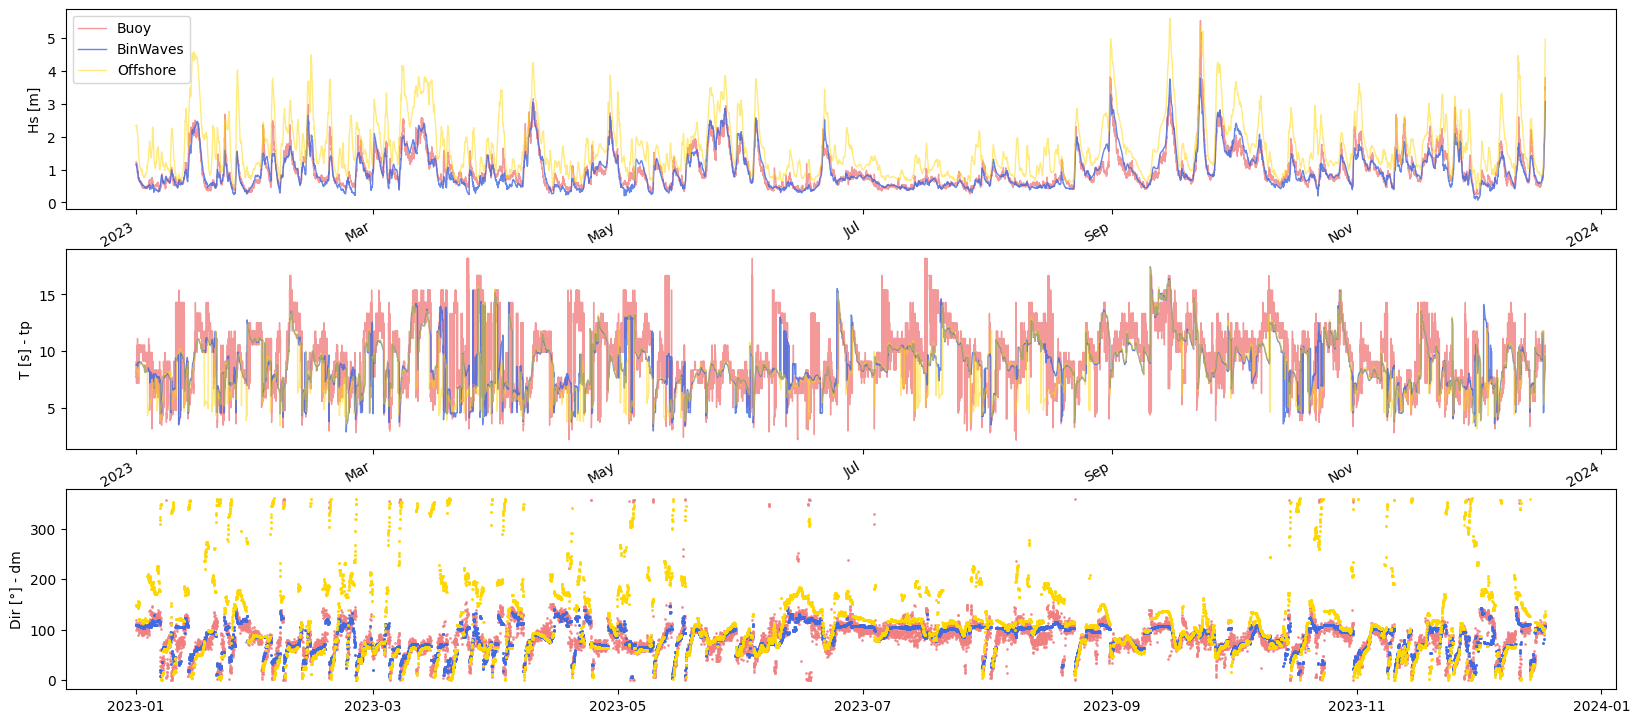

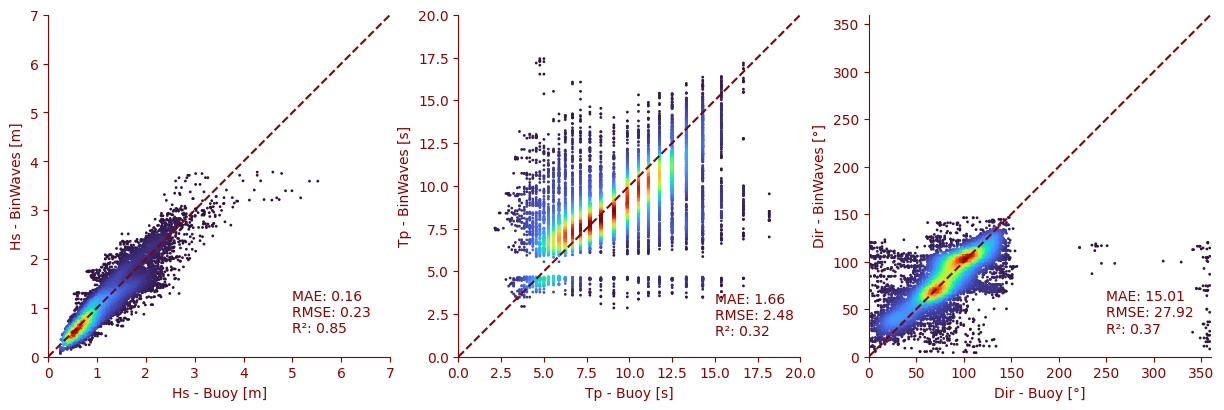

In [6]:
from utils.plotting import plot_wave_series
# First ensure all datasets have unique time values
_, unique_idx_recon = np.unique(reconstructed_onshore_spectra.time, return_index=True)
reconstructed_onshore_spectra = reconstructed_onshore_spectra.isel(time=unique_idx_recon)

_, unique_idx_offshore = np.unique(offshore_spectra.time, return_index=True)
offshore_spectra = offshore_spectra.isel(time=unique_idx_offshore)

# Make sure buoy_waves has unique indices (if not already done)
buoy_waves = buoy_waves[~buoy_waves.index.duplicated(keep='first')]

# Now plot with the deduplicated datasets
plot_wave_series(
    buoy_data=buoy_waves,
    binwaves_data=reconstructed_onshore_spectra
        .sel(time=buoy_waves.index, method="nearest")
        .rename({"kps": "efth"})
        .squeeze()
        .spec,
    offshore_data=offshore_spectra
        .sel(time=buoy_waves.index, method="nearest")
        .spec,
    times=buoy_waves.index.values,
)